In [1]:
import numpy as np 
import pandas as pd 

#### **Type - 1** Single Sample t-test

In [2]:
test_df = pd.read_csv('DataSets/titanic/test.csv')
train_df = pd.read_csv('DataSets/titanic/train.csv').drop(columns=['Survived'])

In [3]:
final_df = pd.concat([test_df, train_df]).sample(1309)

In [4]:
final_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
553,554,3,"Leeni, Mr. Fahim (""Philip Zenni"")",male,22.0,0,0,2620,7.2250,NaN,C
229,1121,2,"Hocking, Mr. Samuel James Metcalfe",male,36.0,0,0,242963,13.0000,NaN,S
587,588,1,"Frolicher-Stehli, Mr. Maxmillian",male,60.0,1,1,13567,79.2000,B41,C
22,23,3,"McGowan, Miss. Anna ""Annie""",female,15.0,0,0,330923,8.0292,NaN,Q
274,1166,3,"Saade, Mr. Jean Nassr",male,NaN,0,0,2676,7.2250,NaN,C


In [5]:
pop = final_df['Age'].dropna()

In [6]:
sample_age = pop.sample(25).values

In [7]:
sample_age

array([19. , 21. , 24. , 55.5, 56. , 51. , 24. , 22. , 32. , 29. , 19. ,
       32. , 28. , 37. , 24. , 21. , 22. , 18. , 31. , 22. , 28.5, 57. ,
       20. , 35. , 17. ])

In [8]:
# H0 = 35 (The mean age is 35)
# H1 < 35 (The mean is less than 35)

In [9]:
# check for normality using Shapiro Wilk test  | pvalue > 0.05, normal distribution
from scipy.stats import shapiro

shapiro_age = shapiro(sample_age)
print(shapiro_age)

ShapiroResult(statistic=np.float64(0.8114134167182218), pvalue=np.float64(0.0003545839925989412))


In [10]:
pop_mean = 35

In [11]:
import scipy.stats as stats

t_statistic, p_value = stats.ttest_1samp(sample_age, pop_mean)

print('t_statistic : ', t_statistic)
print('p_value : ', p_value/2)

t_statistic :  -2.0932998158024616
p_value :  0.023533908209468234


In [12]:
alpha = 0.05

if p_value < alpha:
    print('Reject the Null Hypothesis.')
else:
    print('Fail to reject NuLL Hypothesis.')

Reject the Null Hypothesis.


In [13]:
# lets check 
pop.mean()

np.float64(29.881137667304014)

In [14]:
# so we can see the age is less than 35, now we reject the NuLL Hypothesis.

<Axes: ylabel='Density'>

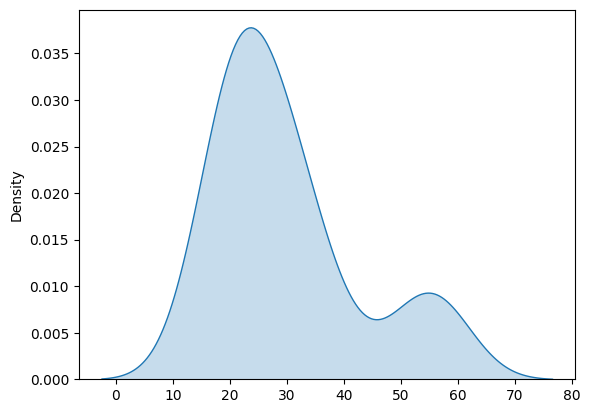

In [15]:
import seaborn as sns

sns.kdeplot(sample_age, fill=True)

#### **Type - 2** Independent 2 sample t-test

In [16]:
final_df

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
553,554,3,"Leeni, Mr. Fahim (""Philip Zenni"")",male,22.0,0,0,2620,7.2250,NaN,C
229,1121,2,"Hocking, Mr. Samuel James Metcalfe",male,36.0,0,0,242963,13.0000,NaN,S
587,588,1,"Frolicher-Stehli, Mr. Maxmillian",male,60.0,1,1,13567,79.2000,B41,C
22,23,3,"McGowan, Miss. Anna ""Annie""",female,15.0,0,0,330923,8.0292,NaN,Q
274,1166,3,"Saade, Mr. Jean Nassr",male,NaN,0,0,2676,7.2250,NaN,C
...,...,...,...,...,...,...,...,...,...,...,...
193,1085,2,"Lingane, Mr. John",male,61.0,0,0,235509,12.3500,NaN,Q
283,1175,3,"Touma, Miss. Maria Youssef",female,9.0,1,1,2650,15.2458,NaN,C
812,813,2,"Slemen, Mr. Richard James",male,35.0,0,0,28206,10.5000,NaN,S
307,308,1,"Penasco y Castellana, Mrs. Victor de Satode (M...",female,17.0,1,0,PC 17758,108.9000,C65,C


In [23]:
pop_male = final_df[final_df['Sex'] == 'male']['Age'].dropna()
pop_female = final_df[final_df['Sex'] == 'female']['Age'].dropna()

In [24]:
# H0 - Mean age male and female are similary 
# H1 - Mean age of male is higher than female 

In [45]:
sample_male = pop_male.sample(25)
sample_female = pop_female.sample(25)
alpha = 0.05

In [46]:
# perform Shapiro-Wilk test for both sexs(check the normality)

from scipy.stats import shapiro

shapiro_male = shapiro(sample_male)
shapiro_female = shapiro(sample_female)

print(f"Shapiro-Wilk Test for Males : {shapiro_male}")
print(f"Shapiro-Wilk Test for Females : {shapiro_female}")

Shapiro-Wilk Test for Males : ShapiroResult(statistic=np.float64(0.9517017009974243), pvalue=np.float64(0.27377927397258656))
Shapiro-Wilk Test for Females : ShapiroResult(statistic=np.float64(0.9798168650634235), pvalue=np.float64(0.8814525463671472))


In [47]:
# Perform levene's test (check for varience that is same of both samples)
from scipy.stats  import levene

levene_test = levene(sample_male, sample_female)
levene_test

LeveneResult(statistic=np.float64(0.3215580531514084), pvalue=np.float64(0.5733152956658989))

In [48]:
# perform the independant 2 sample test 

t_statistic, p_value = stats.ttest_ind(sample_male, sample_female)
print("t_statistic", t_statistic)
print("p_valaue", p_value)

t_statistic 0.1240956214556725
p_valaue 0.9017577856896686


In [49]:
if p_value < alpha:
    print('Reject the Null Hypothesis.')
else:
    print('Fail to reject NuLL Hypothesis.')

Fail to reject NuLL Hypothesis.


In [50]:
pop_male.mean()

np.float64(30.58522796352584)

In [51]:
pop_female.mean()

np.float64(28.68708762886598)

In [53]:
5000*800

4000000